# **PyTorch Training Pipeline Using PyTorch NN**
---

## **Importing Necessary Libraries, Modules and Packages**

In [657]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [658]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [659]:
import torch
import torch.nn as nn

---

## **Importing Dataset, Feature and Target Extraction, Train-Test Split and Preprocessing**

In [660]:
df = pd.read_csv("https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv")
df.sample(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
520,917092,B,9.295,13.90,59.96,257.8,0.13710,0.12250,0.03332,0.024210,...,17.84,67.84,326.6,0.18500,0.2097,0.09996,0.07262,0.3681,0.08982,NaN
82,8611555,M,25.220,24.91,171.50,1878.0,0.10630,0.26650,0.33390,0.184500,...,33.62,211.70,2562.0,0.15730,0.6076,0.64760,0.28670,0.2355,0.10510,NaN
387,902976,B,13.880,16.16,88.37,596.6,0.07026,0.04831,0.02045,0.008507,...,19.97,99.66,745.3,0.08484,0.1233,0.10910,0.04537,0.2542,0.06623,NaN


In [661]:
df.shape

(569, 33)

In [662]:
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

In [663]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [664]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [665]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [666]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [667]:
X_train

array([[-0.20725964,  0.33430297, -0.16990473, ...,  1.64388777,
        -0.14135758,  1.29189177],
       [ 0.82167227,  0.62680907,  0.76353181, ...,  1.23514559,
         0.5203438 , -0.44264499],
       [ 0.04789329,  1.77811309, -0.01500254, ..., -0.89463985,
        -0.88880509, -1.05359966],
       ...,
       [-0.51788059, -0.19922816, -0.54770512, ..., -0.46516221,
         0.14338434, -0.65531908],
       [-0.05472256,  0.43492507, -0.113979  , ..., -0.5366175 ,
        -1.08132945, -0.41668218],
       [ 1.51224921,  0.53554717,  1.49982011, ...,  1.63941249,
         1.86154291, -0.25040971]])

---

## **NumPy Array to Tensor Conversion**

In [668]:
X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).float()
y_test = torch.from_numpy(y_test).float()

---

## **Defining The Model**

In [669]:
class MySimpleNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.linear = nn.Linear(num_features, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)

        return out

In [670]:
loss_fn = nn.BCELoss()

---

## **Training Pipeline**

In [671]:
# Creating the model and defining parameters
model = MySimpleNN(X_train.shape[1])
epochs = 5000
learning_rate = 0.01

indx = []
loss_list = []

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Defining the loop
for epoch in range(1,epochs):

    # Forward Pass
    y_pred = model(X_train)

    # Loss Calculation
    loss = loss_fn(y_pred, y_train.reshape(-1,1))

    # Zero Grad
    optimizer.zero_grad()

    # Backward Pass
    loss.backward()

    # Parameter Update
    optimizer.step()

    indx.append(epoch+1)
    loss_list.append(loss.item())

    # Printing the loss in terms of each epochs
    # print(f"Epoch {epoch}     :      {loss:.4f}")

<Axes: >

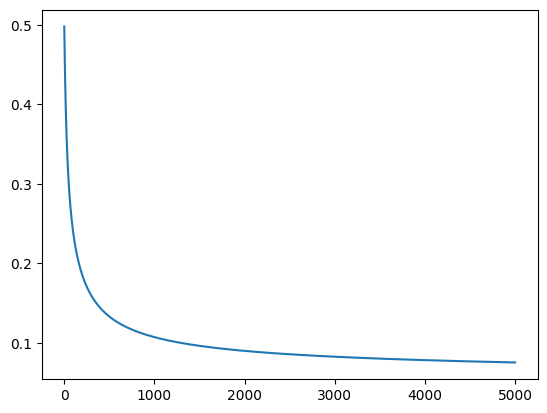

In [672]:
# Visualizing the loss in terms of epochs
sns.lineplot(x=indx, y=loss_list)

---

## **Model Evaluation**

In [673]:
with torch.no_grad(): # To stop tracking
    y_pred = model.forward(X_test)
    y_pred = (y_pred>0.9).float()
    accuracy = (y_pred == y_test).float().mean()
    print(f"Accuracy Score   :    {accuracy.item()*100:.2f}%")

Accuracy Score   :    57.76%


## **Summary**

In [655]:
!pip install torchinfo

In [656]:
from torchinfo import summary
summary(model, input_size=(455,30))

Layer (type:depth-idx)                   Output Shape              Param #
MySimpleNN                               [455, 1]                  --
├─Linear: 1-1                            [455, 1]                  31
├─Sigmoid: 1-2                           [455, 1]                  --
Total params: 31
Trainable params: 31
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.06

---
---